📊 Statistics Learning Journey -> Day 10

##📌Introduction

- **Inferential Statistics helps us estimate population behavior using sample data.**

- **Instead of relying only on point estimates, confidence intervals provide a statistically reliable range that captures uncertainty in the estimation process.**

- **In this project, we use the Student Performance Dataset to explore how confidence intervals are constructed and interpreted using both Z and t procedures.**

- **The project also demonstrates how sample size, variability, and confidence level affect the width and reliability of confidence intervals.**


##📌Problem Statement

- **Educational datasets often contain sample-based observations rather than complete population information.**

- **A single average score may not fully represent true student performance because uncertainty always exists in sampled data.**

- **This project aims to estimate the true population performance of students using inferential statistical techniques such as confidence intervals and statistical estimation.**

- **The analysis also investigates how different statistical factors influence confidence interval width and reliability.**

##📌Objective

***The main objectives of this project are:***

- **To understand point estimation and confidence intervals**
- **To implement Z and t confidence interval procedures using Python**
- **To estimate population mean performance using sample data**
- **To study the impact of sample size on confidence interval width**
- **To compare confidence levels such as 90%, 95%, and 99%**
- **To analyze student performance using inferential statistics**
- **To visualize statistical uncertainty using plots and confidence intervals**

##📌Dataset Information

**Dataset Used:**
* ***Student Performance in Exams Dataset***

**The dataset contains information about student performance in:**
- **Math**
- **Reading**
- **Writing**

**Additional attributes include:**
- **Gender**
- **Lunch type**
- **Test preparation course**
- **Parental education level**

**Source:**

***Kaggle — Students Performance in Exams Dataset***

##📌Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import t
from scipy.stats import norm

##📌Load Dataset

In [28]:
df = pd.read_csv("/content/StudentsPerformance.csv")

##📌Data check

In [3]:
# First 5 rows

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# Shape

df.shape

(1000, 8)

In [6]:
# Check columns

df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

***⚡ Check Missing Values***

In [7]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


##📊Point Estimation


***Point estimation is a statistical technique used to estimate an unknown population parameter using sample data.***

**In this section, we estimate:**
- **Average math score**
- **Average reading score**
- **Average writing score**

**using sample means from the dataset.**

In [10]:

avg_math_score = df["math score"].mean()
avg_reading_score = df["reading score"].mean()
avg_writing_score = df["writing score"].mean()

print("Average Math Score:", avg_math_score)
print("Average Reading Score:", avg_reading_score)
print("Average Writing Score:", avg_writing_score)

Average Math Score: 66.089
Average Reading Score: 69.169
Average Writing Score: 68.054


##📌Interpretation

**The sample mean acts as a point estimate for the population mean.**

**Using the dataset, we estimated the average performance of students in:**
- **Mathematics**
- **Reading**
- **Writing**

**These values provide a single best estimate of overall student performance based on the available sample data.**

##📊Confidence Interval for Math Scores


- ***A confidence interval provides a range of plausible values for the true population mean.***

- ***Instead of relying only on a single estimate, confidence intervals quantify uncertainty in estimation.***

- ***Standard Error (SE) measures the variability of the sample mean across different samples taken from the same population.***

***It tells us how accurately the sample mean estimates the true population mean.***

In [14]:
# Mean of math score

mean_math_score = np.mean(df["math score"])
print("Mean of math score:", mean_math_score)

# Sample standard deviation

sample_standard_deviation = np.std(df["math score"],ddof = 1)
print("Sample standard deviation:",sample_standard_deviation)

# Sample size

n = len(df["math score"])
print("Sample size:", n)

# Standard error

standard_error = sample_standard_deviation / math.sqrt(n)
print("Standard error:", standard_error)

Mean of math score: 66.089
Sample standard deviation: 15.163080096009468
Sample size: 1000
Standard error: 0.47949869446954546


##📌Interpretation

- **The standard error measures how much the sample mean is expected to vary across different samples.**

- **A smaller standard error indicates a more reliable estimate of the population mean.**

- **Since standard error decreases with larger sample sizes, larger datasets generally produce more stable statistical estimates.**

##📊Build 95% Confidence Interval

- ***A 95% Confidence Interval is a statistical range that is likely to contain the true population mean with 95% confidence.***

- ***It provides an estimate of uncertainty around the sample mean instead of relying on a single value.***



In [15]:
# z-value for 95% confidence interval
z = 1.96

# Margin of Error

margin_of_error = z * standard_error
print("Margin of Error:",margin_of_error)

# Lower Confidence Interval

lower_ci = mean_math_score - margin_of_error
print("Lower Confidence Interval:",lower_ci)

# Upper Confidence Interval

upper_ci = mean_math_score + margin_of_error
print("Upper Confidence Interval:",upper_ci)

Margin of Error: 0.9398174411603091
Lower Confidence Interval: 65.14918255883968
Upper Confidence Interval: 67.02881744116031


##📌Interpretation

- **The confidence interval provides a range of plausible values for the true population mean of math scores.**

- **Instead of relying only on the sample mean, the interval captures statistical uncertainty in estimation.**

- **A narrower confidence interval indicates a more precise estimate, while a wider interval reflects greater uncertainty.**

##📊Visualizing the Confidence Interval


- **Visualizing confidence intervals helps us understand uncertainty around the estimated population mean.**

- **The error bars below represent the confidence interval range for math scores.**

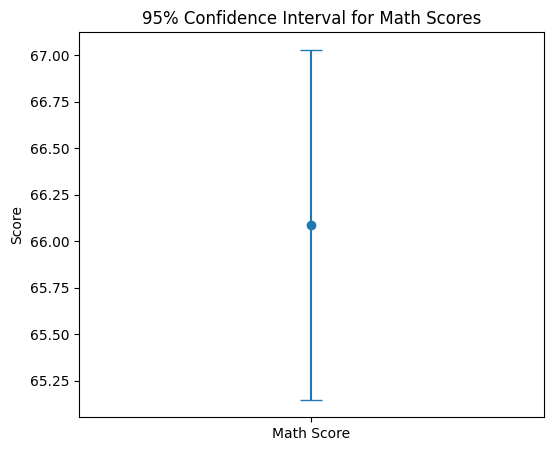

In [40]:
plt.figure(figsize=(6,5))

plt.errorbar(
    x=["Math Score"],
    y=[mean_math_score],
    yerr=[margin_of_error],
    fmt='o',
    capsize=8
)

plt.title("95% Confidence Interval for Math Scores")
plt.ylabel("Score")

plt.savefig("math_score_confidence_interval.png")
plt.show()

## 📌Interpretation

- **The central point represents the sample mean of math scores.**

- **The error bars represent the 95% confidence interval, showing the range within which the true population mean is likely to lie.**

- **Smaller error bars indicate more precise estimates, while larger error bars indicate greater uncertainty.**

##📊Comparing Confidence Levels

- ***The confidence level determines how certain we want to be that the confidence interval contains the true population mean.***

- ***As the confidence level increases, the confidence interval becomes wider because more certainty requires a larger range of values.***


In [19]:
# z-values for different confidence levels
z_90 = 1.645
z_95 = 1.96
z_99 = 2.576

# Margin of Error for 90% CI
moe_90 = z_90 * standard_error

# Margin of Error for 95% CI
moe_95 = z_95 * standard_error

# Margin of Error for 99% CI
moe_99 = z_99 * standard_error

print("90% Margin of Error:", moe_90)
print("95% Margin of Error:", moe_95)
print("99% Margin of Error:", moe_99)

90% Margin of Error: 0.7887753524024023
95% Margin of Error: 0.9398174411603091
99% Margin of Error: 1.2351886369535492


##📌 Interpretation

- **As the confidence level increases, the margin of error also increases.**

- **This causes the confidence interval to become wider because higher confidence requires a larger range to capture the true population mean.**

**Therefore:**
- **90% confidence interval is narrower**
- **95% confidence interval is wider**
- **99% confidence interval is the widest**

## 📊Visualization of Different Confidence Levels

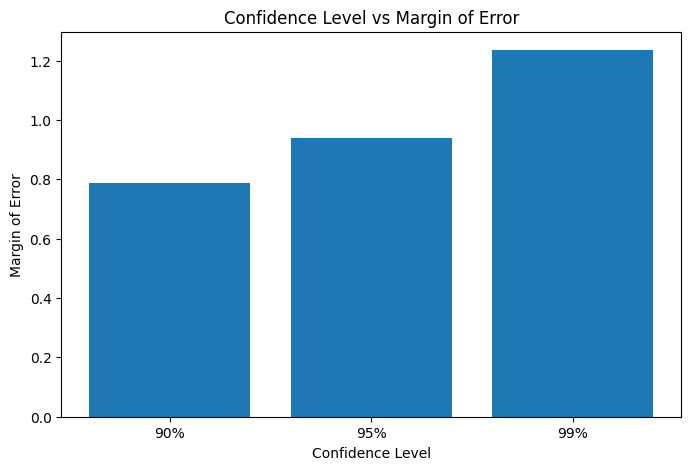

In [39]:
confidence_levels = ["90%", "95%", "99%"]
margin_errors = [moe_90, moe_95, moe_99]

plt.figure(figsize=(8,5))

plt.bar(confidence_levels, margin_errors)

plt.title("Confidence Level vs Margin of Error")
plt.xlabel("Confidence Level")
plt.ylabel("Margin of Error")

plt.savefig("confidence_level_vs_margin_of_error.png")
plt.show()

##📌 Interpretation

- **The graph shows that higher confidence levels produce larger margins of error.**

- **As statistical confidence increases, the confidence interval becomes wider to increase the likelihood of capturing the true population mean.**

- **This demonstrates the trade-off between confidence and precision in inferential statistics.**

# 📊 t-Procedure for Confidence Intervals

- ***In real-world datasets, the population standard deviation is usually unknown.***

- ***In such cases, the t-distribution is used instead of the normal distribution because it accounts for additional uncertainty introduced by estimating population variability from sample data.***

- ***The t-distribution produces wider confidence intervals, especially for smaller sample sizes.***

In [29]:
# Mean
mean_math_score = np.mean(df["math score"])
print("Mean of math score:", mean_math_score)

# Sample size
n = len(df["math score"])
print("Sample size:", n)

# Sample standard deviation
sample_sd = np.std(df["math score"], ddof=1)
print("Sample SD:", sample_sd)

# Standard error
standard_error = sample_sd / math.sqrt(n)
print("Standard Error:", standard_error)

# Degrees of freedom
degrees_of_freedom = n - 1
print("Degrees of freedom:", degrees_of_freedom)

# t-critical value
t_value = t.ppf(0.975, degrees_of_freedom)
print("t-critical value:", t_value)

# Margin of Error
margin_of_error = t_value * standard_error
print("Margin of Error:", margin_of_error)

# Confidence Interval
CI_lower = mean_math_score - margin_of_error
CI_upper = mean_math_score + margin_of_error

print("Lower CI:", CI_lower)
print("Upper CI:", CI_upper)

Mean of math score: 66.089
Sample size: 1000
Sample SD: 15.163080096009468
Standard Error: 0.47949869446954546
Degrees of freedom: 999
t-critical value: 1.9623414611334487
Margin of Error: 0.940940168716949
Lower CI: 65.14805983128305
Upper CI: 67.02994016871695


## 📌Interpretation

- **The t-confidence interval estimates the plausible range for the true population mean of math scores when population standard deviation is unknown.**

- **Compared to the z-procedure, the t-procedure accounts for additional uncertainty using the t-distribution.**

- **This makes the interval slightly wider and statistically more reliable for real-world inference.**

## 📊 Comparison of Z and t Confidence Intervals

- ***Both Z and t procedures are used to construct confidence intervals.***

- ***The Z-procedure is used when population standard deviation is known, while the t-procedure is used when population standard deviation is unknown.***

- ***The t-distribution has heavier tails, which usually produces slightly wider confidence intervals to account for additional uncertainty.***

In [30]:
comparison_table = pd.DataFrame({
    "Procedure": ["Z-Procedure", "t-Procedure"],

    "Lower CI": [
        lower_ci,
        CI_lower
    ],

    "Upper CI": [
        upper_ci,
        CI_upper
    ]
})

comparison_table

,Procedure,Lower CI,Upper CI
0,Z-Procedure,65.149183,67.028817
1,t-Procedure,65.148060,67.029940


## 📌Interpretation

- **The comparison shows that the t-confidence interval is slightly wider than the z-confidence interval.**

- **This occurs because the t-distribution accounts for additional uncertainty when the population standard deviation is unknown.**

- **As sample size increases, the t-distribution gradually approaches the normal distribution, making both intervals more similar.**

## 📊Group Comparison Analysis

- ***Group comparison analysis helps evaluate differences between subpopulations within a dataset.***

- ***Using confidence intervals, we can estimate and compare the average performance of male and female students in mathematics.***

⚡***Male vs Female Confidence Interval Setup***

In [31]:
# Male math scores
male_math_scores = df[df["gender"] == "male"]["math score"]

# Female math scores
female_math_scores = df[df["gender"] == "female"]["math score"]

⚡***Male Group Statistics***

In [32]:
# Mean
male_mean = np.mean(male_math_scores)

# Sample size
male_n = len(male_math_scores)

# Sample standard deviation
male_sd = np.std(male_math_scores, ddof=1)

# Standard error
male_se = male_sd / math.sqrt(male_n)

print("Male Mean:", male_mean)
print("Male SE:", male_se)

Male Mean: 68.72821576763485
Male SE: 0.6539105077571206


⚡***Female Group Statistics***

In [33]:
# Mean
female_mean = np.mean(female_math_scores)

# Sample size
female_n = len(female_math_scores)

# Sample standard deviation
female_sd = np.std(female_math_scores, ddof=1)

# Standard error
female_se = female_sd / math.sqrt(female_n)

print("Female Mean:", female_mean)
print("Female SE:", female_se)

Female Mean: 63.633204633204635
Female SE: 0.6806553785312627


#### 📌Interpretation

- **This analysis allows comparison between male and female student performance in mathematics using inferential statistics.**

- **By computing separate confidence intervals for both groups, we can evaluate whether there is a statistically meaningful difference in their average performance.**

- **Instead of relying on single averages, confidence intervals help us understand uncertainty in group-based comparisons.**

## 📊Confidence Intervals for Male vs Female

⚡***t-Critical Value (95%)***

In [34]:
t_value = t.ppf(0.975, male_n - 1)

⚡***Male Confidence Interval***

In [35]:
male_moe = t_value * male_se

male_ci_lower = male_mean - male_moe
male_ci_upper = male_mean + male_moe

print("Male CI:", male_ci_lower, male_ci_upper)

Male CI: 67.44334167248294 70.01308986278676


⚡***Female Confidence Interval***

In [36]:
female_moe = t_value * female_se

female_ci_lower = female_mean - female_moe
female_ci_upper = female_mean + female_moe

print("Female CI:", female_ci_lower, female_ci_upper)

Female CI: 62.29577932312617 64.9706299432831


⚡***Visualization***

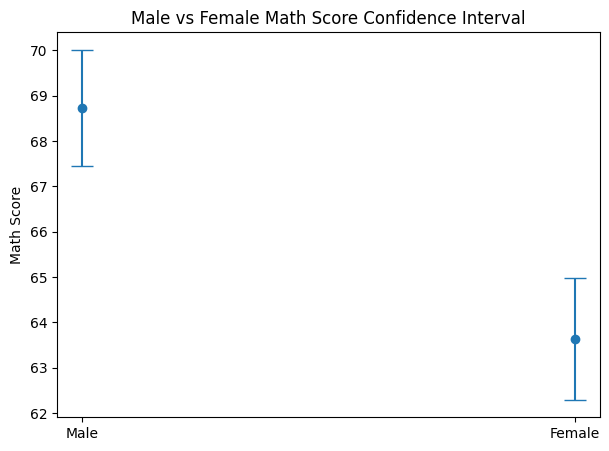

In [38]:
groups = ["Male", "Female"]
means = [male_mean, female_mean]
errors = [male_moe, female_moe]

plt.figure(figsize=(7,5))

plt.errorbar(groups,
             means,
             yerr=errors,
             fmt='o',
             capsize=8
             )

plt.title("Male vs Female Math Score Confidence Interval")
plt.ylabel("Math Score")

plt.savefig("math_score_confidence_interval.png")

plt.show()

####📌Insight

- **The confidence intervals for male and female math scores allow us to compare their average performance while accounting for statistical uncertainty.**

- **If the intervals overlap significantly, it suggests that there may not be a strong statistical difference between the two groups.**

- **If they do not overlap, it may indicate a meaningful difference in performance between male and female students.**

##📊Key Findings

- **Confidence intervals provide a range of plausible values instead of a single point estimate, making statistical inference more reliable.**

- **Increasing sample size reduces the standard error and results in narrower confidence intervals.**

- **Higher confidence levels (90% → 99%) increase the margin of error, leading to wider confidence intervals.**

- **t-distribution produces slightly wider intervals than z-distribution when population standard deviation is unknown.**

- **Male and female math score confidence intervals help compare group performance while accounting for uncertainty.**

##📊Overall Insights

- **This project demonstrates that statistical estimation is not about finding exact values, but about understanding uncertainty in data.**

- **Confidence intervals bridge the gap between sample data and population reality by providing a reliable range of estimation.**

- **Real-world data analysis always involves uncertainty, and inferential statistics helps quantify that uncertainty in a meaningful way.**

##🧾 Conclusion

- **Through this project, we explored how inferential statistics can be used to estimate population parameters using sample data.**

- **We implemented both Z and t confidence interval procedures and analyzed how factors like sample size and confidence level affect the width of intervals.**

- **This project highlights the importance of statistical thinking in data science, especially when making decisions under uncertainty.**

***Data doesn’t give exact answers , it gives us confidence in the range of possibilities.***